# ISyE 6740 Project

In [1]:
import time
import random
import h5py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # the tidy way

In [2]:
from platform import python_version
print(python_version())

3.9.13


## 1. Read PCam data

In [3]:
os.getcwd()
# os.chdir('..')

'C:\\Users\\a_lar\\OneDrive\\00.GTech\\10.ISYE6740_comp_an\\2.Project\\histo\\pcam'

read from h5 files

In [ ]:
PATH = './db/'
data = dict()
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    file = 'camelyonpatch_level_2_split_' + s + '.h5'
    data[s] = h5py.File(PATH + file + '/' +  file, "r")

In [45]:
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    for k in data[s].keys():
        print(s, k)
        dset = data[s][k]
        display(dset.shape)

train_x x


(262144, 96, 96, 3)

train_y y


(262144, 1, 1, 1)

test_x x


(32768, 96, 96, 3)

test_y y


(32768, 1, 1, 1)

In [6]:
# img_arr = X_train[0]
# r,c,l = img_arr.shape
# print("Shape of the 3D matrix obtained from image: ", r, c, l)
# pixels = img_arr.ravel().reshape(img_arr.shape[0]*img_arr.shape[1], 3)
# print("Shape of the 2D matrix obtained by flattening the previous image (ie the 'pixels' matrix): ", pixels.shape)
# print("\n        Original Image:")
# plt.imshow(img_arr)

Create downsamples to test several learners

In [20]:
ntrain = 5000
ntest  = 1000
X_train_0 = data['train_x']['x'][:ntrain]
X_test_0  = data['test_x']['x'][:ntest]
y_train = np.array(data['train_y']['y'][:ntrain]).ravel()
y_test  = np.array(data['test_y']['y'][:ntest]).ravel()
X_train_0.shape, y_train.shape

((5000, 96, 96, 3), (5000,))

Reshape to 2D and standardize:

In [21]:
X_train = np.ones([ntrain, 96*96*3]) * np.inf
X_test  = np.ones([ntest,  96*96*3]) * np.inf
X_train.shape, X_test.shape

((5000, 27648), (1000, 27648))

In [22]:
for i in range(ntrain):
    X_train[i] = np.divide(X_train_0[i].ravel(), 255)
for j in range(ntest):
    X_test[j] = np.divide(X_test_0[j].ravel(), 255)

In [23]:
print('X_train: ', type(X_train), X_train.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test: ', type(X_test), X_test.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train:  <class 'numpy.ndarray'> (5000, 27648)
y_train:  <class 'numpy.ndarray'> (5000,) [0 1 1 1 0]
X_test:  <class 'numpy.ndarray'> (1000, 27648)
y_test:  <class 'numpy.ndarray'> (1000,) [0 1 0 1 1]


In [24]:
np.sum(np.isinf(X_train)), np.sum(np.isinf(X_test))

(0, 0)

Te reshape aftwerwards: 

In [ ]:
# X_train[0].reshape(96,96,3)

In [ ]:
# plt.imshow(X_train[0].reshape(96,96,3)); plt.show()
# plt.imshow(X_test[0].reshape(96,96,3)); plt.show()

## 2. Fit classifiers on 96x96 images

In [25]:
import warnings

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.svm import NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

Define a function to get classification performance metrics:

In [26]:
def get_metrics(predicted_y, test_y):
    d = {}
    acc, bal_acc = accuracy_score(test_y,predicted_y), balanced_accuracy_score(test_y,predicted_y)
    precision, recall, F1_score, support = precision_recall_fscore_support(test_y, predicted_y, average=None)
    d['confusion'] = confusion_matrix(test_y, predicted_y)
    d['accuracy'] = acc
    d['balanced_accuracy'] = bal_acc
    d['precision'] = precision
    d['recall'] = recall
    d['F1_score'] = F1_score
    d['support'] = support
    return d

Define classification parameters for KNN and Neural Net and regularization parameter for SVM:

In [28]:
k = 5   # KNN
C = 5   # SVM regularization parameter
hidden_layer_sizes = (10, 10)
random_state = 101

Define lists with different classifiers:

In [29]:
keys = ['KNN', 'LogReg','SVM', 'KSVM','Net']
pretty_keys = ['KNN', 'Logistic Regression','SVM', 'Kernel SVM', 'Neural Net']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        LogisticRegression(solver = 'liblinear', multi_class='auto', random_state = random_state),
        svm.SVC(kernel='linear', 
                gamma='scale', 
                C=C, 
                decision_function_shape='ovo', 
                random_state = random_state), 
        svm.SVC(kernel='rbf',
                gamma='scale', 
                C=C, 
                random_state = random_state),
        MLPClassifier(hidden_layer_sizes=(100,),
                      max_iter = 10,
                      alpha=1e-4,
                      solver='sgd',
                      verbose=10,
                      random_state=random_state, 
                      learning_rate='adaptive',
                      learning_rate_init=.01)]

Fit classifiers to training data within a loop:

In [30]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs, keys):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
    
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.112994 seconds 


 LogReg finished in 54.718002 seconds 


 SVM finished in 732.502478 seconds 


 KSVM finished in 886.588006 seconds 

Iteration 1, loss = 1.04182339
Iteration 2, loss = 0.68773790
Iteration 3, loss = 0.68509123
Iteration 4, loss = 0.68896868
Iteration 5, loss = 0.67664368
Iteration 6, loss = 0.69303253
Iteration 7, loss = 0.68206823
Iteration 8, loss = 0.69561627
Iteration 9, loss = 0.69373523
Iteration 10, loss = 0.69317820

 Net finished in 197.108467 seconds 

Total elapsed time: 31.184510 minutes 



C:\Users\a_lar\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\a_lar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Report Confusion Marices:

In [31]:
print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 -------------------------  CONFUSION MATRICES  -------------------------

 KNN :


,0,1
0,204,279
1,45,472



 Logistic Regression :


,0,1
0,290,193
1,188,329



 SVM :


,0,1
0,312,171
1,203,314



 Kernel SVM :


,0,1
0,373,110
1,139,378



 Neural Net :


,0,1
0,0,483
1,0,517


In [ ]:
# print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
# np.set_printoptions(precision=2)
# for clf, key in zip(clfs, pretty_keys): 
#     disp = ConfusionMatrixDisplay.from_estimator(
#         clf,
#         X_test,
#         y_test,
#         display_labels=(0,1),
#         cmap=plt.cm.Blues,
#         normalize=None,
#         )
#     disp.ax_.set_title(key)
#     print(key)
#     print(disp.confusion_matrix)

# plt.show()    

Report performance metrics:

In [38]:
# print('-'*25, ' PERFORMANCE METRICS ', '-'*25)
print('\nPRECISION: ')
mts = {'KNN': metrics['KNN']['precision'],
        'Log.Regr.': metrics['LogReg']['precision'],
        'KSVM': metrics['KSVM']['precision']}
display(pd.mtsFrame(mts).round(2))

print('\nRECALL: ')
mts = {'KNN': metrics['KNN']['recall'],
        'Log.Regr.': metrics['LogReg']['recall'],
        'KSVM': metrics['KSVM']['recall']}
display(pd.mtsFrame(mts).round(2))

print('\nF1 score: ')
mts = {'KNN': metrics['KNN']['F1_score'],
        'Log.Regr.': metrics['LogReg']['F1_score'],
        'KSVM': metrics['KSVM']['F1_score']}
display(pd.mtsFrame(mts).round(2))


PRECISION: 


,KNN,Log.Regr.,KSVM
0,0.82,0.61,0.73
1,0.63,0.63,0.77



RECALL: 


,KNN,Log.Regr.,KSVM
0,0.42,0.60,0.77
1,0.91,0.64,0.73



F1 score: 


,KNN,Log.Regr.,KSVM
0,0.56,0.60,0.75
1,0.74,0.63,0.75


Report performance metrics:

In [41]:
print('-'*25, ' PERFORMANCE METRICS ', '-'*25)
print('\nBALANCED ACCURACY: ')
mts = {'KNN': metrics['KNN']['balanced_accuracy'],
        'Log.Regr.': metrics['LogReg']['balanced_accuracy'],
        'KSVM': metrics['KSVM']['balanced_accuracy']}
display(pd.Series(mts).round(2))

print('\nACCURACY: ')
mts = {'KNN': metrics['KNN']['accuracy'],
        'Log.Regr.': metrics['LogReg']['accuracy'],
        'KSVM': metrics['KSVM']['accuracy']}
display(pd.Series(mts).round(2))

print('\nPRECISION: ')
mts = {'KNN': metrics['KNN']['precision'],
        'Log.Regr.': metrics['LogReg']['precision'],
        'KSVM': metrics['KSVM']['precision']}
display(pd.mtsFrame(mts).round(2))

print('\nRECALL: ')
mts = {'KNN': metrics['KNN']['recall'],
        'Log.Regr.': metrics['LogReg']['recall'],
        'KSVM': metrics['KSVM']['recall']}
display(pd.mtsFrame(mts).round(2))

print('\nF1 score: ')
mts = {'KNN': metrics['KNN']['F1_score'],
        'Log.Regr.': metrics['LogReg']['F1_score'],
        'KSVM': metrics['KSVM']['F1_score']}
display(pd.mtsFrame(mts).round(2))

-------------------------  PERFORMANCE METRICS  -------------------------

BALANCED ACCURACY: 


KNN          0.67
Log.Regr.    0.62
KSVM         0.75
dtype: float64


ACCURACY: 


KNN          0.68
Log.Regr.    0.62
KSVM         0.75
dtype: float64


PRECISION: 


,KNN,Log.Regr.,KSVM
0,0.82,0.61,0.73
1,0.63,0.63,0.77



RECALL: 


,KNN,Log.Regr.,KSVM
0,0.42,0.60,0.77
1,0.91,0.64,0.73



F1 score: 


,KNN,Log.Regr.,KSVM
0,0.56,0.60,0.75
1,0.74,0.63,0.75


## 3. Fit classifiers on 32x32 images

Create downsamples to test several learners

In [46]:
ntrain = 10000
ntest  = 2000
X_train_1 = data['train_x']['x'][:ntrain]
X_test_1  = data['test_x']['x'][:ntest]
y_train = np.array(data['train_y']['y'][:ntrain]).ravel()
y_test  = np.array(data['test_y']['y'][:ntest]).ravel()
X_train_1.shape, y_train.shape, X_test_1.shape, y_test.shape

((10000, 96, 96, 3), (10000,), (2000, 96, 96, 3), (2000,))

In [57]:
X_train_1[0][32:32+32,32:32+32].shape

(32, 32, 3)

Reshape to 2D and standardize:

In [59]:
X_train_32 = np.ones([ntrain, 32*32*3]) * np.inf
X_test_32  = np.ones([ntest,  32*32*3]) * np.inf
X_train_32.shape, X_test_32.shape

((10000, 3072), (2000, 3072))

In [60]:
for i in range(ntrain):
    X_train_32[i] = np.divide(X_train_1[i][32:(32*2),32:(32*2)].ravel(), 255)
for j in range(ntest):
    X_test_32[j] = np.divide(X_test_1[j][32:(32*2),32:(32*2)].ravel(), 255)

In [62]:
print('X_train_32: ', type(X_train_32), X_train_32.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test_32: ', type(X_test_32), X_test_32.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train_32:  <class 'numpy.ndarray'> (10000, 3072)
y_train:  <class 'numpy.ndarray'> (10000,) [0 1 1 1 0]
X_test_32:  <class 'numpy.ndarray'> (2000, 3072)
y_test:  <class 'numpy.ndarray'> (2000,) [0 1 0 1 1]


In [63]:
np.sum(np.isinf(X_train_32)), np.sum(np.isinf(X_test_32))

(0, 0)

Define classification parameters for KNN and Neural Net and regularization parameter for SVM:

In [64]:
k = 5   # KNN
C = 10   # SVM regularization parameter
hidden_layer_sizes = (20, 10)
random_state = 101

Define lists with different classifiers:

In [65]:
keys = ['KNN', 'LogReg','SVM', 'KSVM','Net']
pretty_keys = ['KNN', 'Logistic Regression','SVM', 'Kernel SVM', 'Neural Net']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        LogisticRegression(solver = 'liblinear', multi_class='auto', random_state = random_state),
        svm.SVC(kernel='linear', 
                gamma='scale', 
                C=C, 
                decision_function_shape='ovo', 
                random_state = random_state), 
        svm.SVC(kernel='rbf',
                gamma='scale', 
                C=C, 
                random_state = random_state),
        MLPClassifier(hidden_layer_sizes=hidden_layer_sizes,
                      max_iter = 10,
                      alpha=1e-4,
                      solver='sgd',
                      verbose=10,
                      random_state=random_state, 
                      learning_rate='adaptive',
                      learning_rate_init=.01)]

Fit classifiers to training data within a loop:

In [67]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs, keys):
    fitted = clf.fit(X_train_32, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test_32), y_test) 
    
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.038129 seconds 


 LogReg finished in 18.067612 seconds 


 SVM finished in 1524.231496 seconds 


 KSVM finished in 236.848395 seconds 

Iteration 1, loss = 0.68467566
Iteration 2, loss = 0.64515974
Iteration 3, loss = 0.63081272
Iteration 4, loss = 0.62816768
Iteration 5, loss = 0.62037725
Iteration 6, loss = 0.61793258
Iteration 7, loss = 0.60935245
Iteration 8, loss = 0.60688144
Iteration 9, loss = 0.60476784
Iteration 10, loss = 0.59879916

 Net finished in 24.813817 seconds 

Total elapsed time: 30.067010 minutes 



C:\Users\a_lar\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Report Confusion Marices:

In [68]:
print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 -------------------------  CONFUSION MATRICES  -------------------------

 KNN :


,0,1
0,436,583
1,107,874



 Logistic Regression :


,0,1
0,704,315
1,387,594



 SVM :


,0,1
0,677,342
1,384,597



 Kernel SVM :


,0,1
0,778,241
1,276,705



 Neural Net :


,0,1
0,647,372
1,363,618


In [ ]:
# print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
# np.set_printoptions(precision=2)
# for clf, key in zip(clfs, pretty_keys): 
#     disp = ConfusionMatrixDisplay.from_estimator(
#         clf,
#         X_test,
#         y_test,
#         display_labels=(0,1),
#         cmap=plt.cm.Blues,
#         normalize=None,
#         )
#     disp.ax_.set_title(key)
#     print(key)
#     print(disp.confusion_matrix)

# plt.show()    

Report performance metrics:

In [72]:
print('-'*25, ' PERFORMANCE METRICS ', '-'*25)
print('\nBALANCED ACCURACY: ')
mts = {'KNN': metrics['KNN']['balanced_accuracy'],
        'Log.Regr.': metrics['LogReg']['balanced_accuracy'],
        'SVM': metrics['SVM']['balanced_accuracy'],
        'KSVM': metrics['KSVM']['balanced_accuracy'],
        'Net': metrics['Net']['balanced_accuracy']}
display(pd.Series(mts).round(2))

print('\nACCURACY: ')
mts = {'KNN': metrics['KNN']['accuracy'],
        'Log.Regr.': metrics['LogReg']['accuracy'],
        'SVM': metrics['SVM']['accuracy'],
        'KSVM': metrics['KSVM']['accuracy'],
        'Net': metrics['Net']['accuracy']}
display(pd.Series(mts).round(2))

print('\nPRECISION: ')
mts = {'KNN': metrics['KNN']['precision'],
        'Log.Regr.': metrics['LogReg']['precision'],
        'SVM': metrics['SVM']['precision'],
        'KSVM': metrics['KSVM']['precision'],
        'Net': metrics['Net']['precision']}
display(pd.DataFrame(mts).round(2))

print('\nRECALL: ')
mts = {'KNN': metrics['KNN']['recall'],
        'Log.Regr.': metrics['LogReg']['recall'],
        'SVM': metrics['SVM']['recall'],
        'KSVM': metrics['KSVM']['recall'],
        'Net': metrics['Net']['recall']}
display(pd.DataFrame(mts).round(2))

print('\nF1 score: ')
mts = {'KNN': metrics['KNN']['F1_score'],
        'Log.Regr.': metrics['LogReg']['F1_score'],
        'SVM': metrics['SVM']['F1_score'],
        'KSVM': metrics['KSVM']['F1_score'],
        'Net': metrics['Net']['F1_score']}
display(pd.DataFrame(mts).round(2))

-------------------------  PERFORMANCE METRICS  -------------------------

BALANCED ACCURACY: 


KNN          0.66
Log.Regr.    0.65
SVM          0.64
KSVM         0.74
Net          0.63
dtype: float64


ACCURACY: 


KNN          0.66
Log.Regr.    0.65
SVM          0.64
KSVM         0.74
Net          0.63
dtype: float64


PRECISION: 


,KNN,Log.Regr.,SVM,KSVM,Net
0,0.8,0.65,0.64,0.74,0.64
1,0.6,0.65,0.64,0.75,0.62



RECALL: 


,KNN,Log.Regr.,SVM,KSVM,Net
0,0.43,0.69,0.66,0.76,0.63
1,0.89,0.61,0.61,0.72,0.63



F1 score: 


,KNN,Log.Regr.,SVM,KSVM,Net
0,0.56,0.67,0.65,0.75,0.64
1,0.72,0.63,0.62,0.73,0.63


AdaBoost

In [102]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

TIC0, TIC = time.time(), time.time() 
AdaBoost_metrics = {}
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200)

fitted = bdt.fit(X_train_32, y_train)
TOC = time.time()
print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
TIC = TOC
# metrics[key] = get_metrics(fitted.predict(X_test_32), y_test) 

TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 Net finished in 296.657795 seconds 

Total elapsed time: 4.944297 minutes 



In [104]:
AdaBoost_metrics = get_metrics(fitted.predict(X_test_32), y_test) 
AdaBoost_metrics

{'confusion': array([[719, 300],
        [254, 727]], dtype=int64),
 'accuracy': 0.723,
 'balanced_accuracy': 0.7233371247020175,
 'precision': array([0.74, 0.71]),
 'recall': array([0.71, 0.74]),
 'F1_score': array([0.72, 0.72]),
 'support': array([1019,  981], dtype=int64)}

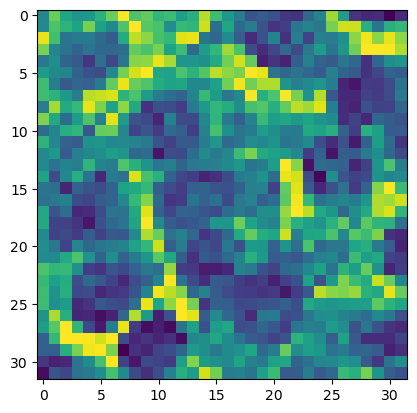

In [97]:
plt.imshow(X_train_32[0].reshape([32,32,3])[:,:,0])

In [107]:
X_train_32.shape, y_train.shape

((10000, 3072), (10000,))

In [ ]:
from time import time

import numpy as np
import scipy.stats as stats

from sklearn.datasets import load_digits
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
# Utility function to report best scores
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results["rank_test_score"] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print(
                "Mean validation score: {0:.3f} (std: {1:.3f})".format(
                    results["mean_test_score"][candidate],
                    results["std_test_score"][candidate],
                )
            )
            print("Parameters: {0}".format(results["params"][candidate]))
            print("")

In [110]:
# get some data
X, y = X_train_32, y_train

# build a classifier
clf = KNeighborsClassifier()

# specify parameters and distributions to sample from
param_dist = {"n_neighbors": stats.randint(5, 25)}

# run randomized search
n_iter_search = 10
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)

start = time()
random_search.fit(X, y)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time() - start), n_iter_search))

report(random_search.cv_results_)

# use a full grid over all parameters
param_grid = {
   "n_neighbors": [5,10,15,20,25]}

# run grid search
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time()
grid_search.fit(X, y)

print(
    "GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time() - start, len(grid_search.cv_results_["params"]))
)
report(grid_search.cv_results_)

RandomizedSearchCV took 38.41 seconds for 15 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.639 (std: 0.007)
Parameters: {'n_neighbors': 6}

Model with rank: 2
Mean validation score: 0.638 (std: 0.007)
Parameters: {'n_neighbors': 8}

Model with rank: 3
Mean validation score: 0.637 (std: 0.007)
Parameters: {'n_neighbors': 7}

Model with rank: 3
Mean validation score: 0.637 (std: 0.007)
Parameters: {'n_neighbors': 7}

GridSearchCV took 13.81 seconds for 5 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.640 (std: 0.008)
Parameters: {'n_neighbors': 5}

Model with rank: 2
Mean validation score: 0.636 (std: 0.009)
Parameters: {'n_neighbors': 10}

Model with rank: 3
Mean validation score: 0.628 (std: 0.008)
Parameters: {'n_neighbors': 15}



In [114]:
# get some data
X, y = X_train_32[:5000], y_train[:5000]

# build a classifier
clf = svm.SVC(kernel='rbf',random_state = random_state)
              
# specify parameters and distributions to sample from
param_dist = {"gamma": stats.uniform(0,3),
              "C":stats.randint(1,20) }

# run randomized search
n_iter_search = 5
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)

start = time()
random_search.fit(X, y)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time() - start), n_iter_search))

report(random_search.cv_results_)

# use a full grid over all parameters
param_grid = {"gamma": [0.5,1,2],
              "C":[5,10,15]}

# run grid search
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time()
grid_search.fit(X, y)

print(
    "GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time() - start, len(grid_search.cv_results_["params"]))
)
report(grid_search.cv_results_)

RandomizedSearchCV took 582.42 seconds for 5 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.568 (std: 0.006)
Parameters: {'C': 2, 'gamma': 0.2772002723184599}

Model with rank: 2
Mean validation score: 0.538 (std: 0.002)
Parameters: {'C': 3, 'gamma': 2.011451374149522}

Model with rank: 2
Mean validation score: 0.538 (std: 0.002)
Parameters: {'C': 18, 'gamma': 1.9187961191978735}

GridSearchCV took 1036.88 seconds for 9 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.555 (std: 0.007)
Parameters: {'C': 5, 'gamma': 0.5}

Model with rank: 1
Mean validation score: 0.555 (std: 0.007)
Parameters: {'C': 10, 'gamma': 0.5}

Model with rank: 1
Mean validation score: 0.555 (std: 0.007)
Parameters: {'C': 15, 'gamma': 0.5}



In [117]:
# get some data
X, y = X_train_32[:2000], y_train[:2000]

# build a classifier
clf =  AdaBoostClassifier(DecisionTreeClassifier(max_depth=25))
              
# specify parameters and distributions to sample from
param_dist = {"n_estimators": stats.randint(25,150)}

# run randomized search
n_iter_search = 5
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)

start = time()
random_search.fit(X, y)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time() - start), n_iter_search))

report(random_search.cv_results_)

RandomizedSearchCV took 710.72 seconds for 5 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.667 (std: 0.057)
Parameters: {'n_estimators': 100}

Model with rank: 2
Mean validation score: 0.663 (std: 0.016)
Parameters: {'n_estimators': 126}

Model with rank: 3
Mean validation score: 0.660 (std: 0.018)
Parameters: {'n_estimators': 110}



In [118]:
# use a full grid over all parameters
param_grid = {"n_estimators": [75,100,125]}

# run grid search
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time()
grid_search.fit(X, y)

print(
    "GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time() - start, len(grid_search.cv_results_["params"]))
)
report(grid_search.cv_results_)

GridSearchCV took 501.82 seconds for 3 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.669 (std: 0.028)
Parameters: {'n_estimators': 125}

Model with rank: 2
Mean validation score: 0.660 (std: 0.024)
Parameters: {'n_estimators': 100}

Model with rank: 3
Mean validation score: 0.650 (std: 0.038)
Parameters: {'n_estimators': 75}



### Final round with tuned params

In [121]:
ntrain = 5000
ntest  = 5000
X_train_2 = data['train_x']['x'][:ntrain]
X_test_2  = data['test_x']['x'][:ntest]
y_train = np.array(data['train_y']['y'][:ntrain]).ravel()
y_test  = np.array(data['test_y']['y'][:ntest]).ravel()
X_train_1.shape, y_train.shape, X_test_1.shape, y_test.shape

((10000, 96, 96, 3), (5000,), (2000, 96, 96, 3), (5000,))

Reshape to 2D and standardize:

In [122]:
X_train_32_2 = np.ones([ntrain, 32*32*3]) * np.inf
X_test_32_2  = np.ones([ntest,  32*32*3]) * np.inf
X_train_32_2.shape, X_test_32_2.shape

((5000, 3072), (5000, 3072))

In [123]:
for i in range(ntrain):
    X_train_32_2[i] = np.divide(X_train_2[i][32:(32*2),32:(32*2)].ravel(), 255)
for j in range(ntest):
    X_test_32_2[j] = np.divide(X_test_2[j][32:(32*2),32:(32*2)].ravel(), 255)

In [124]:
print('X_train_32: ', type(X_train_32_2), X_train_32_2.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test_32: ', type(X_test_32_2), X_test_32_2.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train_32:  <class 'numpy.ndarray'> (5000, 3072)
y_train:  <class 'numpy.ndarray'> (5000,) [0 1 1 1 0]
X_test_32:  <class 'numpy.ndarray'> (5000, 3072)
y_test:  <class 'numpy.ndarray'> (5000,) [0 1 0 1 1]


In [125]:
np.sum(np.isinf(X_train_32_2)), np.sum(np.isinf(X_test_32_2))

(0, 0)

Define Tuned classification parameters 

In [126]:
k = 5   # KNN
C, gamma = 5, 0.5   # SVM regularization parameter
n_estimators = 100
random_state = 201

Define lists with different classifiers:

In [127]:
keys = ['KNN', 'KSVM','AdaBoost']
pretty_keys = ['KNN', 'KSVM','AdaBoost']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        svm.SVC(kernel='rbf',
                gamma=gamma, 
                C=C, 
                random_state = random_state),
        AdaBoostClassifier(
            DecisionTreeClassifier(max_depth=10), 
            n_estimators=n_estimators)]

Fit classifiers to training data within a loop:

In [130]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs, keys):
    fitted = clf.fit(X_train_32_2, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test_32_2), y_test) 
    
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.013001 seconds 


 KSVM finished in 27.397432 seconds 


 AdaBoost finished in 1384.455078 seconds 

Total elapsed time: 23.567575 minutes 



Report Confusion Marices:

In [131]:
print('\n', '-'*25, ' CONFUSION MATRICES ', '-'*25)
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 -------------------------  CONFUSION MATRICES  -------------------------

 KNN :


,0,1
0,950,1514
1,225,2311



 KSVM :


,0,1
0,220,2244
1,14,2522



 AdaBoost :


,0,1
0,1576,888
1,579,1957


Report performance metrics:

In [133]:
print('-'*25, ' PERFORMANCE METRICS ', '-'*25)
print('\nBALANCED ACCURACY: ')
mts = {'KNN': metrics['KNN']['balanced_accuracy'],
        'KSVM': metrics['KSVM']['balanced_accuracy'],
        'AdaBoost': metrics['AdaBoost']['balanced_accuracy']}
display(pd.Series(mts).round(2))

print('\nACCURACY: ')
mts = {'KNN': metrics['KNN']['accuracy'],
        'KSVM': metrics['KSVM']['accuracy'],
        'AdaBoost': metrics['AdaBoost']['accuracy']}
display(pd.Series(mts).round(2))

print('\nPRECISION: ')
mts = {'KNN': metrics['KNN']['precision'],
        'KSVM': metrics['KSVM']['precision'],
        'AdaBoost': metrics['AdaBoost']['precision']}
display(pd.DataFrame(mts).round(2))

print('\nRECALL: ')
mts = {'KNN': metrics['KNN']['recall'],
        'KSVM': metrics['KSVM']['recall'],
        'AdaBoost': metrics['AdaBoost']['recall']}
display(pd.DataFrame(mts).round(2))

print('\nF1 score: ')
mts = {'KNN': metrics['KNN']['F1_score'],
        'KSVM': metrics['KSVM']['F1_score'],
        'AdaBoost': metrics['AdaBoost']['F1_score']}
display(pd.DataFrame(mts).round(2))

-------------------------  PERFORMANCE METRICS  -------------------------

BALANCED ACCURACY: 


KNN         0.65
KSVM        0.54
AdaBoost    0.71
dtype: float64


ACCURACY: 


KNN         0.65
KSVM        0.55
AdaBoost    0.71
dtype: float64


PRECISION: 


,KNN,KSVM,AdaBoost
0,0.81,0.94,0.73
1,0.60,0.53,0.69



RECALL: 


,KNN,KSVM,AdaBoost
0,0.39,0.09,0.64
1,0.91,0.99,0.77



F1 score: 


,KNN,KSVM,AdaBoost
0,0.52,0.16,0.68
1,0.73,0.69,0.73
